# Feature Selection — Hierarchical Funnel

**Purpose:** Select features using a structured, reproducible approach — not an arbitrary vote.

**Framework:**
1. **LightGBM gain ranking** — primary selector, aligned with final model architecture
2. **Boruta confirmation** — validates top features aren't fitting noise
3. **LASSO** — generates an alternative, parsimonious feature subset
4. **Competing subsets** — LGBM top-K, LASSO selected, intersection
5. **Cross-validation tie-breaker** — best subset wins on empirical AUCPR

**Data source:** `analytics_dataset` train split, after imputation.

## 0. Setup

In [1]:
from __future__ import annotations

import os
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from lightgbm import LGBMClassifier
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

# Notebook may be launched from anywhere — ensure mlops/ is on sys.path.
_NB_DIR = Path.cwd()
_PROJECT_ROOT = _NB_DIR
for _p in [_NB_DIR, *_NB_DIR.parents]:
    if (_p / "src" / "config.py").exists():
        _PROJECT_ROOT = _p
        break
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

# All relative paths (artifacts, policy CSV) resolve from repo root.
os.chdir(str(_PROJECT_ROOT))

from src.bigquery import run_query
from src.config import (
    FULL_TABLE_REF, LABEL_COLUMN, NON_FEATURE_COLUMNS,
    SPLIT_COLUMN, SPLITS, PROJECT_ID,
)
from src.imputer import MissingnessImputer

warnings.filterwarnings("ignore", category=FutureWarning)

RID = datetime.now(timezone.utc).strftime("%Y%m%dt%H%M%S")
ARTIFACTS_DIR = _PROJECT_ROOT / "artifacts" / "feature_selection" / RID
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Run ID:     {RID}")
print(f"Artifacts:  {ARTIFACTS_DIR.relative_to(_PROJECT_ROOT)}")
print(f"Table:      {FULL_TABLE_REF}")

Run ID:     20260618t173842
Artifacts:  artifacts/feature_selection/20260618t173842
Table:      trim-icon-498815-a0.readmission.analytics_dataset


### 0.1 Load & Impute

Pull train and validation splits. Apply the missingness policy — fit imputer on train only, transform both. Label-encode categoricals so numeric methods work.

In [2]:
def load_data():
    split_list = ", ".join(f"'{s}'" for s in SPLITS.values())
    sql = f"""
        SELECT *
        FROM `{FULL_TABLE_REF}`
        WHERE {SPLIT_COLUMN} IN ({split_list})
    """
    df = run_query(sql)

    train_df = df[df[SPLIT_COLUMN] == SPLITS["train"]].reset_index(drop=True)
    val_df = df[df[SPLIT_COLUMN] == SPLITS["validation"]].reset_index(drop=True)

    drop_cols = [c for c in NON_FEATURE_COLUMNS if c in train_df.columns and c != LABEL_COLUMN]
    drop_cols.append(SPLIT_COLUMN)
    train_df = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
    val_df = val_df.drop(columns=[c for c in drop_cols if c in val_df.columns])

    imputer = MissingnessImputer()
    X_train = imputer.fit_transform(train_df)
    X_val = imputer.transform(val_df)

    y_train = X_train.pop(LABEL_COLUMN).astype(int)
    y_val = X_val.pop(LABEL_COLUMN).astype(int)

    return X_train, X_val, y_train, y_val, imputer


def encode_categoricals(X_train, X_val):
    """Label-encode categoricals consistently across train/val."""
    Xt = X_train.copy()
    Xv = X_val.copy()
    encoders = {}
    for col in Xt.columns:
        if Xt[col].dtype in ("object", "category") or str(Xt[col].dtype) == "category":
            le = LabelEncoder()
            combined = pd.concat([Xt[col].astype(str), Xv[col].astype(str)])
            le.fit(combined)
            Xt[col] = le.transform(Xt[col].astype(str))
            Xv[col] = le.transform(Xv[col].astype(str))
            encoders[col] = le
    return Xt, Xv, encoders


X_train_raw, X_val_raw, y_train, y_val, imputer = load_data()
X_train_enc, X_val_enc, encoders = encode_categoricals(X_train_raw, X_val_raw)

print(f"Train: {X_train_enc.shape}  Val: {X_val_enc.shape}")
print(f"Features after imputation: {X_train_enc.shape[1]}")
print(f"Label prevalence (train): {y_train.mean():.4f}")

Train: (247687, 74)  Val: (48924, 74)
Features after imputation: 74
Label prevalence (train): 0.2094


## 1. Primary Selector — LightGBM Gain Ranking

Train LightGBM on all features. Extract gain importance — the total reduction in loss from splits on each feature. This is our primary ranking because the final model will also be a gradient-boosted tree.

In [4]:
lgbm = LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    random_state=42, verbose=-1,
)
lgbm.fit(
    X_train_enc.fillna(0), y_train,
    eval_set=[(X_val_enc.fillna(0), y_val)],
)

val_aucpr = average_precision_score(y_val, lgbm.predict_proba(X_val_enc.fillna(0))[:, 1])
print(f"LGBM val AUCPR: {val_aucpr:.4f}  (HOSPITAL baseline: 0.3325)")

gain_df = pd.DataFrame({
    "feature": X_train_enc.columns,
    "gain": lgbm.feature_importances_,
    "gain_pct": lgbm.feature_importances_ / lgbm.feature_importances_.sum() * 100,
}).sort_values("gain", ascending=False).reset_index(drop=True)
gain_df["gain_rank"] = range(1, len(gain_df) + 1)
gain_df["cumulative_gain"] = gain_df["gain_pct"].cumsum()

print(f"\nFeatures with any gain: {(gain_df.gain > 0).sum()}/{len(gain_df)}")

print("\n=== Top 25 by gain ===")
for _, r in gain_df.head(25).iterrows():
    bar = "█" * max(1, int(r["gain_pct"] * 3))
    print(f"  {r['gain_rank']:3d}. {r['feature']:<38s} {r['gain_pct']:5.1f}%  {bar}")

out = ARTIFACTS_DIR / "lgbm_gain.csv"
gain_df.to_csv(out, index=False)
print(f"\nSaved: {out.name}")

LGBM val AUCPR: 0.4012  (HOSPITAL baseline: 0.3325)

Features with any gain: 47/74

=== Top 25 by gain ===
    1. discharge_location                       5.7%  ████████████████
    2. age                                      5.3%  ████████████████
    3. recent_ed_visits                         4.8%  ██████████████
    4. prior_inpatient_days                     4.3%  ████████████
    5. index_los_days                           4.1%  ████████████
    6. admission_type                           3.6%  ██████████
    7. medication_order_count                   3.3%  █████████
    8. medication_count                         3.2%  █████████
    9. race                                     3.1%  █████████
   10. procedure_count                          2.9%  ████████
   11. glucose_max                              2.8%  ████████
   12. prior_admission_count                    2.8%  ████████
   13. rbc_last                                 2.6%  ███████
   14. diagnosis_count                  

### 1.1 Cumulative gain — where to draw the line?

In [5]:
for t in [50, 70, 80, 90, 95]:
    n = (gain_df["cumulative_gain"] >= t).idxmax()
    print(f"  {t}% of gain captured by top {n + 1} features")

  50% of gain captured by top 14 features
  70% of gain captured by top 23 features
  80% of gain captured by top 28 features
  90% of gain captured by top 34 features
  95% of gain captured by top 38 features


## 2. Boruta Confirmation

Take the top LGBM features and ask: "Do these consistently outperform randomized shadows?" Boruta validates — it doesn't vote. Rejected features are flagged as potentially spurious.

In [6]:
BORUTA_TOP_N = 30
boruta_features = gain_df.head(BORUTA_TOP_N)["feature"].tolist()
print(f"Running Boruta on top {BORUTA_TOP_N} LGBM features...")

rf = RandomForestClassifier(n_jobs=-1, max_depth=7, random_state=42)
boruta = BorutaPy(rf, n_estimators="auto", perc=100, random_state=42, verbose=0)

X_boruta = X_train_enc[boruta_features].fillna(0)
boruta.fit(X_boruta.values, y_train.values)

decisions = ["Confirmed" if s else "Rejected" for s in boruta.support_]
boruta_df = pd.DataFrame({
    "feature": boruta_features,
    "decision": decisions,
    "boruta_rank": boruta.ranking_,
    "lgbm_gain_pct": [gain_df[gain_df.feature == f].iloc[0]["gain_pct"] for f in boruta_features],
}).sort_values(["decision", "boruta_rank"])

Running Boruta on top 30 LGBM features...


### Boruta Evaluation

Compare Boruta's verdict against LGBM's gain ranking. A feature that LGBM ranks highly but Boruta rejects is a red flag — the model may be fitting noise. A feature both agree on is solid.

In [11]:
# Agreement — compare Boruta verdicts against LGBM ranking
boruta_set = set(boruta_df[boruta_df.decision == "Confirmed"]["feature"])
lgbm_set = set(gain_df.head(BORUTA_TOP_N)["feature"])
agreement = boruta_set & lgbm_set
print(f"\n=== Agreement (both methods, top {BORUTA_TOP_N}) ===")
print(f"  In both: {len(agreement)}")
print(f"  Boruta-confirmed but outside LGBM top-{BORUTA_TOP_N}: {len(boruta_set - lgbm_set)}")
print(f"  LGBM top-{BORUTA_TOP_N} but rejected by Boruta: {len(lgbm_set - boruta_set)}")


=== Agreement (both methods, top 30) ===
  In both: 30
  Boruta-confirmed but outside LGBM top-30: 0
  LGBM top-30 but rejected by Boruta: 0


## 3. LASSO — Alternative Subset Generator

LASSO produces a parsimonious, linear-perspective feature set. Used to construct Subset B (LASSO-selected) and Subset C (intersection with LGBM).

In [12]:
scaler = StandardScaler()
n_sample = min(50000, len(X_train_enc))
idx = np.random.RandomState(42).choice(len(X_train_enc), n_sample, replace=False)
Xt_s = scaler.fit_transform(X_train_enc.fillna(0).iloc[idx])
yt_s = y_train.iloc[idx]

lasso = LogisticRegression(penalty="l1", solver="saga", C=0.1, max_iter=500, random_state=42)
lasso.fit(Xt_s, yt_s)

lasso_df = pd.DataFrame({
    "feature": X_train_enc.columns,
    "coefficient": lasso.coef_[0],
    "abs_coef": np.abs(lasso.coef_[0]),
    "selected": lasso.coef_[0] != 0,
}).sort_values("abs_coef", ascending=False).reset_index(drop=True)

n_sel = lasso_df["selected"].sum()
print(f"LASSO selected {n_sel}/{len(lasso_df)} features\n")

print("=== Top 15 LASSO features ===")
for _, r in lasso_df[lasso_df.selected].head(15).iterrows():
    print(f"  {r.feature:<38s} {r.coefficient:+.4f}")

out = ARTIFACTS_DIR / "lasso_coefficients.csv"
lasso_df.to_csv(out, index=False)
print(f"\nSaved: {out.name}")

/Users/danherman/Desktop/enterprise_clinical_copilot/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


LASSO selected 55/74 features

=== Top 15 LASSO features ===
  prior_admission_count                  +0.2146
  oncology_flag                          +0.1762
  hemoglobin_last                        -0.1538
  admission_type                         -0.1409
  rbc_last                               -0.1157
  rdw_min                                +0.1127
  recent_ed_visits                       +0.1078
  age                                    -0.1052
  rbc_delta                              +0.1026
  sodium_min                             -0.0865
  gender                                 +0.0782
  hemoglobin_max                         +0.0771
  glucose_last                           +0.0647
  prior_inpatient_days                   +0.0614
  glucose_min                            -0.0578

Saved: lasso_coefficients.csv


## 4. Construct Competing Subsets

- **A (LGBM top-K):** Top 25 by gain, Boruta-confirmed — trust the tree
- **B (LASSO selected):** Non-zero coefficients — linear, parsimonious
- **C (Intersection):** Only features in both A and B — strict consensus

In [13]:
LGBM_TOP_K = 25
lgbm_confirmed = set(boruta_df[boruta_df.decision == "Confirmed"]["feature"])
subset_a = [f for f in gain_df.head(LGBM_TOP_K)["feature"] if f in lgbm_confirmed]
subset_b = lasso_df[lasso_df.selected]["feature"].tolist()
subset_c = [f for f in subset_a if f in subset_b]

print(f"Subset A (LGBM top-{LGBM_TOP_K}, Boruta-confirmed): {len(subset_a)} features")
print(f"Subset B (LASSO selected):                        {len(subset_b)} features")
print(f"Subset C (Intersection A ∩ B):                     {len(subset_c)} features")

subsets = {"A_LGBM": subset_a, "B_LASSO": subset_b, "C_Intersection": subset_c}

Subset A (LGBM top-25, Boruta-confirmed): 25 features
Subset B (LASSO selected):                        55 features
Subset C (Intersection A ∩ B):                     19 features


## 5. Cross-Validation Tie-Breaker

5-fold CV with XGBoost per subset. The subset with the highest mean validation AUCPR wins.

In [14]:
from xgboost import XGBClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, features in subsets.items():
    X_sub = X_train_enc[features].fillna(0)
    fold_scores = []

    for fold, (tr_idx, vl_idx) in enumerate(cv.split(X_sub, y_train)):
        X_tr = X_sub.iloc[tr_idx]
        X_vl = X_sub.iloc[vl_idx]
        model = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                              random_state=42, verbosity=0)
        model.fit(X_tr, y_train.iloc[tr_idx])
        preds = model.predict_proba(X_vl)[:, 1]
        fold_scores.append(average_precision_score(y_train.iloc[vl_idx], preds))

    results[name] = {
        "features": features,
        "n_features": len(features),
        "mean_aucpr": np.mean(fold_scores),
        "std_aucpr": np.std(fold_scores),
        "fold_scores": fold_scores,
    }
    print(f"  {name:<20s}  {len(features):2d} features  "
          f"AUCPR = {results[name]['mean_aucpr']:.4f} "
          f"(±{results[name]['std_aucpr']:.4f})")

winner = max(results, key=lambda k: results[k]["mean_aucpr"])
print(f"\n✓ Winner: {winner}  (AUCPR = {results[winner]['mean_aucpr']:.4f})")

  A_LGBM                25 features  AUCPR = 0.4089 (±0.0087)
  B_LASSO               55 features  AUCPR = 0.4094 (±0.0078)
  C_Intersection        19 features  AUCPR = 0.4057 (±0.0080)

✓ Winner: B_LASSO  (AUCPR = 0.4094)


### 5.1 CV score distribution

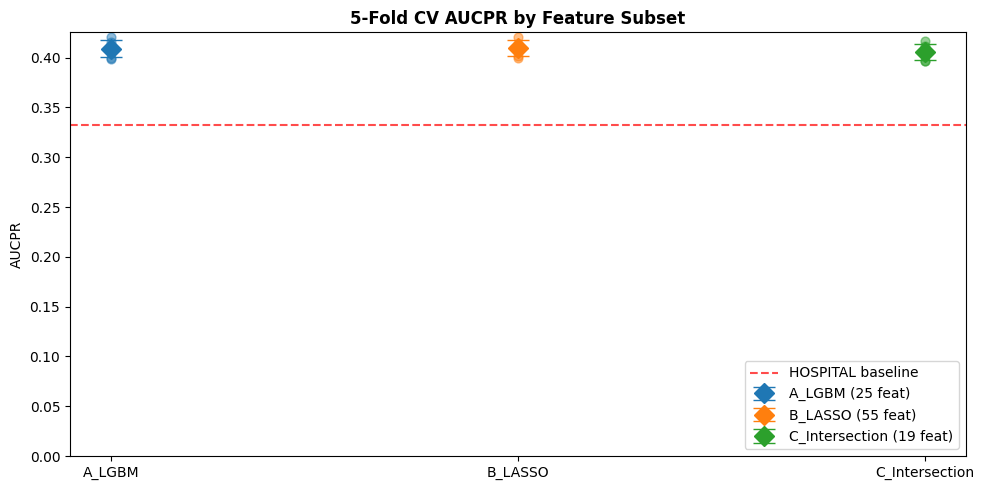

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
positions = range(len(results))

colors = {"A_LGBM": "#1f77b4", "B_LASSO": "#ff7f0e", "C_Intersection": "#2ca02c"}
for i, (name, res) in enumerate(results.items()):
    ax.scatter([i] * 5, res["fold_scores"], alpha=0.5, s=40, color=colors[name])
    ax.errorbar(i, res["mean_aucpr"], yerr=res["std_aucpr"],
                fmt="D", capsize=8, markersize=10, linewidth=2,
                color=colors[name], label=f"{name} ({res['n_features']} feat)")

ax.axhline(y=0.3325, color="red", linestyle="--", alpha=0.7, label="HOSPITAL baseline")
ax.set_xticks(positions)
ax.set_xticklabels(results.keys())
ax.set_ylabel("AUCPR")
ax.set_title("5-Fold CV AUCPR by Feature Subset", fontweight="bold")
ax.legend(loc="lower right")
ax.set_ylim(0.0, None)
plt.tight_layout()
plt.show()

## D. Decision Curve Analysis

DCA answers: if a clinician used this model to decide who to intervene on, would patients be better off?

- **Treat All** — intervene on every patient (catches all readmissions, maximum false positives)
- **Treat None** — intervene on no one (no false positives, misses all readmissions)
- **Model** — intervene only when predicted risk ≥ threshold

A model has clinical value where its curve is *above* both defaults.

Model adds clinical value for risk thresholds 4%–50%


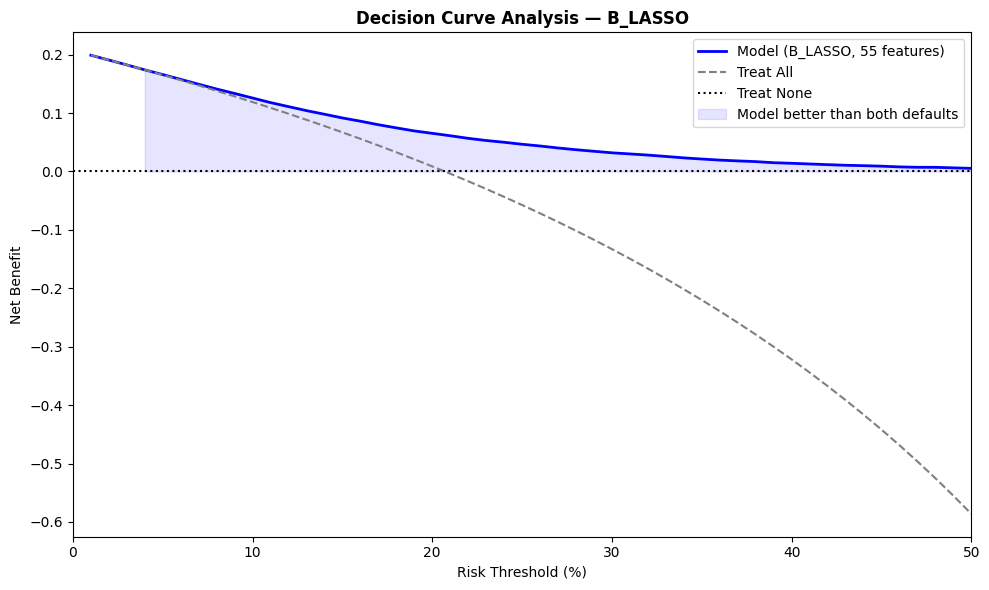

In [17]:
# Train winning model on full train, predict val
X_tr = X_train_enc[winner_features].fillna(0)
X_vl = X_val_enc[winner_features].fillna(0)

model = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                       random_state=42, verbosity=0)
model.fit(X_tr, y_train)
probs = model.predict_proba(X_vl)[:, 1]

# DCA: net benefit at each threshold
thresholds = np.linspace(0.01, 0.50, 50)
n = len(y_val)

net_benefit_model = []
net_benefit_all = []

for t in thresholds:
    pred_pos = probs >= t
    tp = (pred_pos & (y_val == 1)).sum()
    fp = (pred_pos & (y_val == 0)).sum()
    # Net benefit = TP/N - FP/N × (t / (1-t))
    nb = tp / n - (fp / n) * (t / (1 - t))
    net_benefit_model.append(nb)
    # Treat all: TP = all positives, FP = all negatives
    nb_all = (y_val == 1).sum() / n - ((y_val == 0).sum() / n) * (t / (1 - t))
    net_benefit_all.append(nb_all)

# Treat none: net benefit = 0 at all thresholds

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds * 100, net_benefit_model, "b-", linewidth=2,
        label=f"Model ({winner}, {len(winner_features)} features)")
ax.plot(thresholds * 100, net_benefit_all, "gray", linestyle="--",
        label="Treat All")
ax.axhline(y=0, color="black", linestyle=":", label="Treat None")

# Shade the region where the model adds value
ax.fill_between(thresholds * 100, net_benefit_model, 0,
                 where=(np.array(net_benefit_model) > 0) & (np.array(net_benefit_model) > np.array(net_benefit_all)),
                 alpha=0.1, color="blue", label="Model better than both defaults")

ax.set_xlabel("Risk Threshold (%)")
ax.set_ylabel("Net Benefit")
ax.set_title(f"Decision Curve Analysis — {winner}", fontweight="bold")
ax.legend(loc="upper right")
ax.set_xlim(0, 50)

# Annotate the threshold range where model is useful
model_better = np.where((np.array(net_benefit_model) > 0) & (np.array(net_benefit_model) > np.array(net_benefit_all)))[0]
if len(model_better) > 0:
    t_start = thresholds[model_better[0]] * 100
    t_end = thresholds[model_better[-1]] * 100
    print(f"Model adds clinical value for risk thresholds {t_start:.0f}%–{t_end:.0f}%")
else:
    print("Model does not outperform both defaults at any threshold")

plt.tight_layout()
plt.show()

## 6. Export Final Shortlist

In [16]:
winner_features = results[winner]["features"]

shortlist_df = pd.DataFrame({
    "feature": winner_features,
    "decision": "KEEP",
    "source": winner,
})
for i, row in shortlist_df.iterrows():
    g = gain_df[gain_df.feature == row["feature"]]
    if len(g):
        shortlist_df.at[i, "lgbm_gain_pct"] = round(g.iloc[0]["gain_pct"], 2)
        shortlist_df.at[i, "lgbm_rank"] = int(g.iloc[0]["gain_rank"])

out = ARTIFACTS_DIR / "feature_shortlist.csv"
shortlist_df.to_csv(out, index=False)
print(f"Saved: {out.name}")
print(f"\nFinal shortlist: {len(shortlist_df)} features ({winner})")
print(f"CV AUCPR: {results[winner]['mean_aucpr']:.4f} (±{results[winner]['std_aucpr']:.4f})")

print("\n=== Final Features ===")
for _, r in shortlist_df.iterrows():
    print(f"  {r['feature']:<38s}  gain={r['lgbm_gain_pct']:5.1f}%  rank={r['lgbm_rank']:.0f}")

Saved: feature_shortlist.csv

Final shortlist: 55 features (B_LASSO)
CV AUCPR: 0.4094 (±0.0078)

=== Final Features ===
  prior_admission_count                   gain=  2.8%  rank=12
  oncology_flag                           gain=  2.1%  rank=24
  hemoglobin_last                         gain=  1.4%  rank=34
  admission_type                          gain=  3.6%  rank=6
  rbc_last                                gain=  2.6%  rank=13
  rdw_min                                 gain=  2.2%  rank=20
  recent_ed_visits                        gain=  4.8%  rank=3
  age                                     gain=  5.3%  rank=2
  rbc_delta                               gain=  1.9%  rank=26
  sodium_min                              gain=  1.3%  rank=35
  gender                                  gain=  0.8%  rank=39
  hemoglobin_max                          gain=  2.1%  rank=25
  glucose_last                            gain=  2.4%  rank=16
  prior_inpatient_days                    gain=  4.3%  rank=4
  

## 7. Summary

| Step | Method | Role |
|---|---|---|
| 1 | LightGBM gain | Primary selector — ranks all features |
| 2 | Boruta | Confirmation gate — rejects features indistinguishable from noise |
| 3 | LASSO | Subset generator — alternative linear-perspective set |
| 4 | Three subsets | LGBM top-K, LASSO selected, intersection |
| 5 | 5-fold CV | Tie-breaker — best subset wins on empirical AUCPR |
| 6 | Export | `feature_shortlist.csv` with winning features |

**HOSPITAL baseline AUCPR:** 0.3325